# Reinventing Hacker News
A project by Cielo for CSE 158 at UC San Diego

Reviewers: please feel free to speed up my video, I talked slower than usual just so I could properly enunciate everything.


In [22]:
import re, requests, json, time, math
from dateutil import parser
from pathlib import Path
from urllib.parse import urlparse
from IPython.display import HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_similarity
import tqdm as tqdm
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', 300)

## Precursor: About Hacker News
Hacker News is a social news site ran by Y Combinator. It is similar in function and appearance to Reddit, but with a central focus on tech-and-science-related news articles. Notably, the site displays the same top 30 stories to every user, with or without an account.

## 1) Why not make a recommendation feed that specifically displays stories in the order that we predict will interest the user?

I will predict which Hacker News stories within the past week are most likely to interest a particular user.
I evaluate this by trying out Jaccard similarity as well as Support Vector Machine, to compare a user’s past interactions with new posts that they have not yet interacted with. I’ll use the site’s existing popularity points system as a baseline, given that this is the default home page setup.

## 2) Data collection and preprocessing

Using the Algolia API, I’ll fetch recent stories, cache results locally, and fetch comment authors in order to build up a database of each user’s interactions.

Algolia rate limit: I will call the API less than 10,000 times due to the rate limit, but this should result in an appropriately sized database for me to work with.

In [2]:
BASE_SEARCH_URL = 'https://hn.algolia.com/api/v1/search_by_date'
BASE_ITEM_URL = 'https://hn.algolia.com/api/v1/items/'
CACHE_DIR = Path('data/hn_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cache_path_for_stories(page, hitsPerPage):
    return CACHE_DIR / f'stories_page{page}_per{hitsPerPage}.json'

def fetch_hn_stories(page, hitsPerPage, use_cache=True, timeout=30):
    p = cache_path_for_stories(page, hitsPerPage)
    if use_cache and p.exists():
        try:
            return json.loads(p.read_text(encoding='utf-8'))
        except Exception:
            pass
    params = {'tags': 'story', 'page': page, 'hitsPerPage': hitsPerPage}
    r = requests.get(BASE_SEARCH_URL, params=params, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    hits = j.get('hits', [])
    try:
        p.write_text(json.dumps(hits), encoding='utf-8')
    except Exception:
        pass
    return hits

def fetch_hn_item(item_id, use_cache=True, timeout=30):
    p = CACHE_DIR / f'item_{item_id}.json'
    if use_cache and p.exists():
        try:
            return json.loads(p.read_text(encoding='utf-8'))
        except Exception:
            pass
    r = requests.get(BASE_ITEM_URL + str(item_id), timeout=timeout)
    r.raise_for_status()
    j = r.json()
    try:
        p.write_text(json.dumps(j), encoding='utf-8')
    except Exception:
        pass
    return j

def fetch_recent_stories(pages, hitsPerPage, use_cache=True, polite_delay=0.3):
    'Fetch multiple pages and return combined list of story dicts.'
    all_hits = []
    for pg in range(pages):
        hits = fetch_hn_stories(page=pg, hitsPerPage=hitsPerPage, use_cache=use_cache)
        all_hits.extend(hits)
        time.sleep(polite_delay)
    return all_hits

In [3]:
# Simple normalization
def normalize_stories(hits):
    rows = []
    for h in hits:
        rows.append({
            'id': str(h.get('objectID')),
            'title': h.get('title') or '',
            'url': h.get('url') or '',
            'points': int(h.get('points') or 0),
            'author': h.get('author') or '',
            'created_at': h.get('created_at')
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        try:
            # Parse timestamps, coerce errors, normalize to UTC then cast to tz-naive datetime64[ns]
            s = pd.to_datetime(df['created_at'], errors='coerce', utc=True).astype('datetime64[ns]')
            df['created_at'] = s
        except Exception:
            pass
        df['domain'] = df['url'].apply(lambda u: urlparse(u).netloc.lower() if u else '')
    return df


def collect_comment_authors_for_story(item_json):
    authors = []
    def walk(node):
        if not node or not isinstance(node, dict):
            return
        a = node.get('author')
        if a:
            authors.append(a)
        for c in node.get('children', []) or []:
            walk(c)
    walk(item_json)
    return authors


### Fetching the data
The following cell creates a locally cached database of user profiles containing all of a user’s authored posts and comments, at least within the 10,000 calls of data I was limited to. With this database created, we can explore some data about user behavior. 

I used paging as the caching mechanism in order to keep my computer from exploding during processing.

In [5]:
# Fetch 9000 recent stories (90 pages of 100 each)
hits = fetch_recent_stories(pages=90, hitsPerPage=100)
stories_df = normalize_stories(hits)
print('Fetched', len(stories_df), 'stories')
display(stories_df.head())
# Build a lightweight user->story interaction map from comments on these stories
# We'll anonymize raw usernames to anonymous IDs and store the mapping under data/hn_cache/anon_map.json
user_interactions = {}  # anon_id -> set(story_id)
anon_map = {}  # raw_username -> anon_id
next_anon = [1]
def get_anon(u):
    if not u: return None
    if u in anon_map: return anon_map[u]
    aid = f'user_{next_anon[0]:06d}'
    anon_map[u] = aid
    next_anon[0] += 1
    return aid
for h in tqdm.tqdm(hits):
    iid = h.get('objectID')
    try:
        item = fetch_hn_item(iid)
    except Exception:
        continue
    authors = collect_comment_authors_for_story(item)
    for a in authors:
        aid = get_anon(a)
        if not aid:
            continue
        user_interactions.setdefault(aid, set()).add(str(iid))
# Save anon_map for reproducibility (avoid exposing raw usernames in downstream outputs)
try:
    (CACHE_DIR / 'anon_map.json').write_text(json.dumps(anon_map), encoding='utf-8')
except Exception:
    pass
# Also ensure story authors are anonymized (assign anon IDs for story authors too)
for a in stories_df['author'].dropna().unique():
    if a and a not in anon_map:
        get_anon(a)
# add an author_anon column to stories_df for downstream displays
stories_df['author_anon'] = stories_df['author'].map(lambda a: anon_map.get(a, ''))

Fetched 1000 stories


,id,title,url,points,author,created_at,domain
0,46103273,Amoral Drift in AI Corporate Governance,https://harvardlawreview.org/print/vol-138/amoral-drift-in-ai-corporate-governance/,1,measurablefunc,2025-12-01T03:44:53Z,harvardlawreview.org
1,46103270,Seeing Theory - A Visual Introduction to Probability and Statistics,https://seeing-theory.brown.edu/,1,Anon84,2025-12-01T03:44:07Z,seeing-theory.brown.edu
2,46103265,Estimate how often a Python library is used in a public GitHub repository,https://github.com/recite/user,1,neehao,2025-12-01T03:43:03Z,github.com
3,46103227,Python terminal app as Android Phone app,,1,dharmatech,2025-12-01T03:35:19Z,
4,46103220,OpenTelemetry for MCP,https://glama.ai/blog/2025-11-29-open-telemetry-for-model-context-protocol-mcp-analytics-and-agent-observability,1,punkpeye,2025-12-01T03:34:01Z,glama.ai


100%|██████████| 1000/1000 [00:13<00:00, 71.95it/s]


In [6]:
# Filter users with >= 3 interactions if available
min_interactions = 3
eligible_users = [u for u,s in user_interactions.items() if len(s) >= min_interactions]
print('Users discovered (anon):', len(user_interactions), ', eligible:', len(eligible_users))

Users discovered (anon): 3842 , eligible: 367


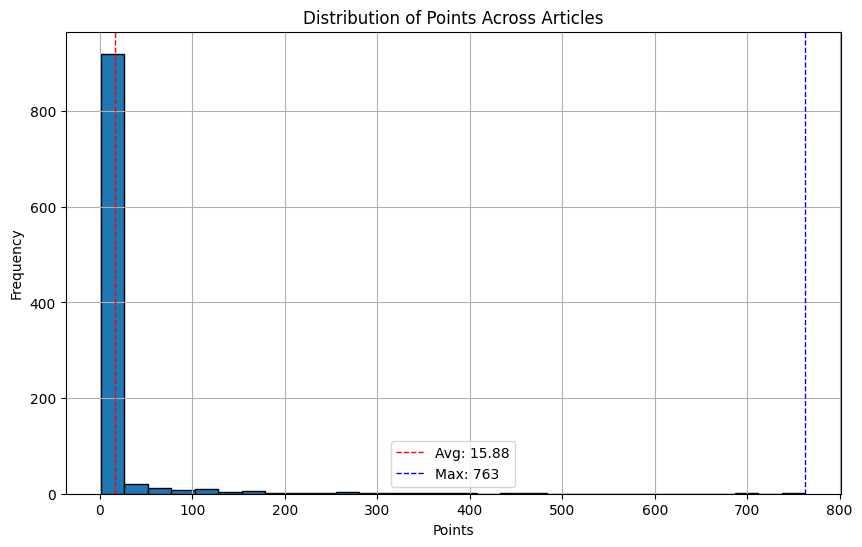

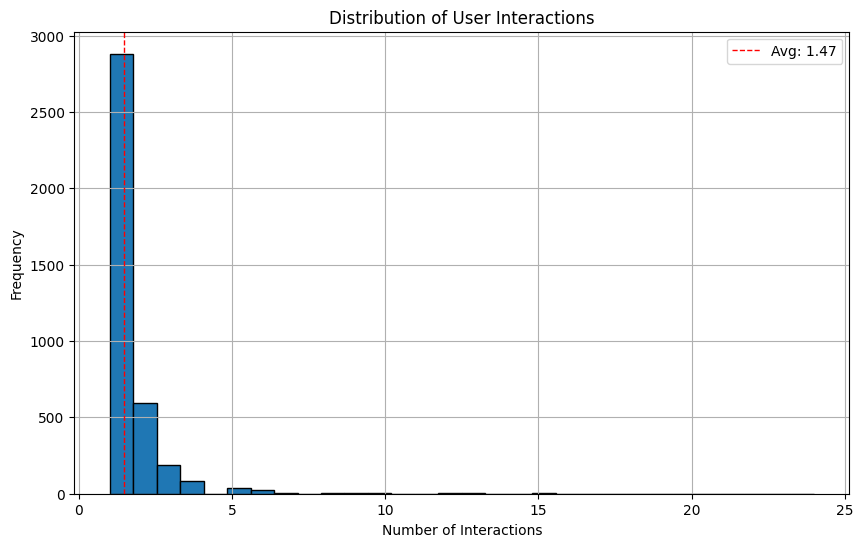

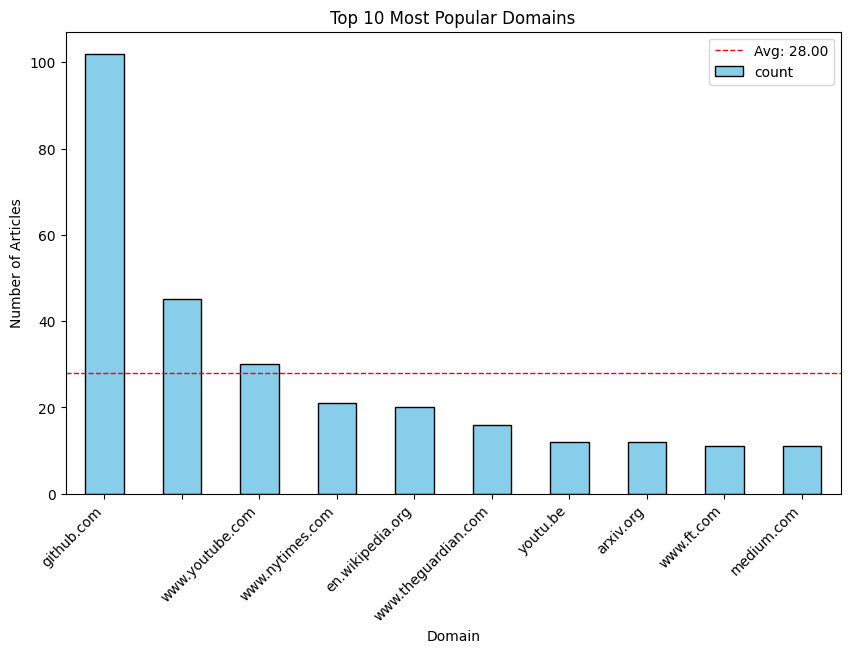

In [7]:
# Data exploration: Popular articles, user stats, and domains
# Most popular articles by points
popular_articles = stories_df.nlargest(10, 'points')[['title', 'points', 'author_anon', 'domain']]
#print('Top 10 most popular articles:')
#display(popular_articles)

# Average number of interactions per user
avg_interactions = pd.Series([len(v) for v in user_interactions.values()]).mean()
#print(f'Average number of interactions per user: {avg_interactions:.2f}')

# Most popular domain mentioned in articles
domain_counts = stories_df['domain'].value_counts()
most_popular_domain = domain_counts.idxmax()
most_popular_domain_count = domain_counts.max()
#print(f'Most popular domain: {most_popular_domain} with {most_popular_domain_count} articles')

# Distribution of points across articles
plt.figure(figsize=(10, 6))
stories_df['points'].hist(bins=30, edgecolor='black')
plt.axvline(stories_df['points'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Avg: {stories_df["points"].mean():.2f}')
plt.axvline(stories_df['points'].max(), color='blue', linestyle='dashed', linewidth=1, label=f'Max: {stories_df["points"].max()}')
plt.title('Distribution of Points Across Articles')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Visualizing user interactions
user_interaction_counts = pd.Series([len(v) for v in user_interactions.values()])
plt.figure(figsize=(10, 6))
user_interaction_counts.hist(bins=30, edgecolor='black')
plt.axvline(user_interaction_counts.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Avg: {user_interaction_counts.mean():.2f}')
plt.title('Distribution of User Interactions')
plt.xlabel('Number of Interactions')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Visualizing most popular domains
domain_counts_top = domain_counts.head(10)
plt.figure(figsize=(10, 6))
domain_counts_top.plot(kind='bar', color='skyblue', edgecolor='black')
plt.axhline(domain_counts_top.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Avg: {domain_counts_top.mean():.2f}')
plt.title('Top 10 Most Popular Domains')
plt.xlabel('Domain')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## 3) Modeling

I implemented two baselines and one recommendation model:
- Popularity baseline: rank by global popularity points.
- Jaccard similarity baseline: compute Jaccard similarities between article titles vs. a user's interacted titles and rank by highest score.
- Logistic Regression: a text classifier that uses TF-IDF between user interaction history and article title, cosine similarity, and story popularity.

In [8]:
# Tokenizer helper for Jaccard
def tokenize_title(t):
    if not t: return []
    words = re.findall(r'\b\w+\b', t.lower())
    return [w for w in words if len(w)>1]

def jaccard_score(user_titles, candidate_title):
    # user_titles: list of strings; candidate_title: string
    cand_set = set(tokenize_title(candidate_title))
    if not cand_set: return 0.0
    user_set = set()
    for t in user_titles:
        user_set |= set(tokenize_title(t))
    if not user_set: return 0.0
    inter = len(user_set & cand_set)
    union = len(user_set | cand_set)
    return inter/union if union>0 else 0.0

### Logistic Regression
Features used:
- TF-IDF to compare titles
- Cosine similarity between user history and candidate article title
- Global popularity points and recency

In [9]:
# Build title TF-IDF over the fetched stories
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
titles = stories_df['title'].fillna('').astype(str).tolist()
if len(titles) >= 1:
    tfidf = vectorizer.fit_transform(titles)
else:
    tfidf = None

# Map story id -> index in tfidf / stories_df
id_to_idx = {str(r['id']): i for i,r in stories_df.reset_index().to_dict(orient='index').items()}

def user_profile_vector(user, user_interactions, tfidf_matrix):
    ids = list(user_interactions.get(user, []))
    idxs = [id_to_idx[i] for i in ids if i in id_to_idx]
    if not idxs or tfidf_matrix is None:
        return None
    mat = tfidf_matrix[idxs,:]
    # Use pandas for mean calculation
    return pd.DataFrame(mat.toarray()).mean(axis=0).values

def build_feature_row(user_profile_vec, cand_idx, stories_df):
    # candidate tfidf vector
    cand_vec = tfidf[cand_idx] if tfidf is not None else None
    if user_profile_vec is None or cand_vec is None:
        sim = 0.0
    else:
        sim = cosine_similarity(user_profile_vec.reshape(1,-1), cand_vec).ravel()[0]
    points = stories_df.iloc[cand_idx]['points']
    created_at = stories_df.iloc[cand_idx]['created_at']
    recency_hours = (pd.Timestamp.now(tz=None) - created_at).total_seconds()/3600 if pd.notnull(created_at) else 0
    return [sim, points, recency_hours]

### Prepare dataset for training
I constructed one global model containing the aforementioned features for each user.

In [10]:
# Ensure 'created_at' column is converted to timezone-naive datetimes (UTC)
# Coerce parsing errors and normalize to UTC then cast to tz-naive datetime64[ns]
stories_df['created_at'] = pd.to_datetime(stories_df['created_at'], errors='coerce', utc=True).dt.tz_localize(None)

# Build training examples (may be small for demo)
rows = []
for user in eligible_users:
    profile_vec = user_profile_vector(user, user_interactions, tfidf)
    pos_ids = user_interactions[user]
    # sample positives that exist in id_to_idx
    pos_idxs = [id_to_idx[i] for i in pos_ids if i in id_to_idx]
    # negatives: sample other stories
    all_idxs = set(range(len(stories_df)))
    neg_pool = list(all_idxs - set(pos_idxs))
    # Use pandas for sampling negatives
    if neg_pool:
        neg_sample = pd.Series(neg_pool).sample(n=min(len(pos_idxs)*2, max(1,len(neg_pool))), replace=False).tolist()
    else:
        neg_sample = []
    for pi in pos_idxs:
        feat = build_feature_row(profile_vec, pi, stories_df)
        rows.append({'user': user, 'idx': pi, 'label': 1, 'sim': feat[0], 'points': feat[1], 'recency_hours': feat[2]})
    for ni in neg_sample:
        feat = build_feature_row(profile_vec, int(ni), stories_df)
        rows.append({'user': user, 'idx': int(ni), 'label': 0, 'sim': feat[0], 'points': feat[1], 'recency_hours': feat[2]})

df_train = pd.DataFrame(rows)
print('Prepared rows:', len(df_train))
if not df_train.empty:
    display(df_train.head())


Prepared rows: 4704


,user,idx,label,sim,points,recency_hours
0,user_000001,860,1,0.516681,265,67.231130
1,user_000001,0,1,0.430264,1,35.404464
2,user_000001,605,1,0.516681,2,56.318908
3,user_000001,234,1,0.430264,4,43.477242
4,user_000001,552,1,0.430264,76,53.415020


In [15]:
# Train a logistic regression model on feature columns
if not df_train.empty:
    X = df_train[['sim','points','recency_hours']].fillna(0).values
    y = df_train['label'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probs) if len(np.unique(y_test))>1 else float('nan')
    print('Logistic Regression AUC (test):', auc)
else:
    print('No training data — increase fetch size or lower min_interactions for demo')

Logistic Regression AUC (test): 0.9942751288659794


## 4) Evaluation 

Listed below are the following evaluations per each baseline and the LogReg model
- AUC
- Precision@k
- My custom feed display, with a side-by-side of user history and the model's recommended posts.

In [16]:
def precision_at_k(recommended_idxs, true_idxs, k=10):
    if len(recommended_idxs) == 0: return 0.0
    topk = recommended_idxs[:k]
    hit = sum([1 for i in topk if i in set(true_idxs)])
    return hit / k

def evaluate_user(user, model=None, topk=10):
    # generate candidate list (all stories in the sample) and rank by model or baselines
    profile_vec = user_profile_vector(user, user_interactions, tfidf)
    true_idxs = [id_to_idx[i] for i in user_interactions.get(user, []) if i in id_to_idx]
    if not true_idxs: return {'precision_at_10': float('nan')}
    cand_scores = []
    for idx in range(len(stories_df)):
        if model is None:
            # baseline: popularity score only (points)
            score_pop = stories_df.iloc[idx]['points']
            cand_scores.append((idx, score_pop))
        else:
            feat = build_feature_row(profile_vec, idx, stories_df)
            # Use pandas for array creation
            X = pd.DataFrame([feat]).values
            prob = model.predict_proba(X)[0,1] if hasattr(model,'predict_proba') else model.decision_function(X)
            cand_scores.append((idx, float(prob)))
    ranked = [i for i,s in sorted(cand_scores, key=lambda x:-x[1])]
    return {'precision_at_10': precision_at_k(ranked, true_idxs, k=10)}

# Compare Jaccard baseline vs Logistic Regression for an example user (if available)
if eligible_users:
    u = eligible_users[0]
    print('Example user:', u)
    # Jaccard ranking
    user_titles = [stories_df.iloc[id_to_idx[i]]['title'] for i in user_interactions[u] if i in id_to_idx]
    j_scores = [(idx, jaccard_score(user_titles, stories_df.iloc[idx]['title'])) for idx in range(len(stories_df))]
    j_ranked = [i for i,s in sorted(j_scores, key=lambda x:-x[1])]
    j_prec = precision_at_k(j_ranked, [id_to_idx[i] for i in user_interactions[u] if i in id_to_idx], k=10)
    print('Jaccard precision@10 (example):', j_prec)
    if 'model' in globals():
        lr_eval = evaluate_user(u, model=model, topk=10)
        print('Logistic Regression precision@10 (example):', lr_eval['precision_at_10'])
else:
    print('No eligible users for demo; increase fetch window or lower min_interactions')

Example user: user_000001
Jaccard precision@10 (example): 0.5
Logistic Regression precision@10 (example): 0.5


In [25]:
out = widgets.Output()
user_options = sorted(eligible_users)[:500] if eligible_users else []
user_dd = widgets.Dropdown(options=user_options, description='User')
k_slider = widgets.IntSlider(value=10, min=1, max=30, description='k')
method_dd = widgets.Dropdown(options=['popularity','jaccard','logreg'], description='method')

def show_recs(user, k, method):
    with out:
        out.clear_output(wait=True)
        if not user:
            print('No user selected')
            return
        # compute user's history indices and exclude them from recommendations
        hist_idxs = set([id_to_idx[i] for i in user_interactions.get(user, []) if i in id_to_idx])
        # compute ranking with scores
        scores = []
        if method == 'popularity':
            for i in range(len(stories_df)):
                if i in hist_idxs:
                    continue
                scores.append((i, float(stories_df.iloc[i]['points'])))
        elif method == 'jaccard':
            user_titles = [stories_df.iloc[id_to_idx[i]]['title'] for i in user_interactions[user] if i in id_to_idx]
            for i in range(len(stories_df)):
                if i in hist_idxs:
                    continue
                scores.append((i, float(jaccard_score(user_titles, stories_df.iloc[i]['title']))))
        else:
            profile_vec = user_profile_vector(user, user_interactions, tfidf)
            for i in range(len(stories_df)):
                if i in hist_idxs:
                    continue
                feat = build_feature_row(profile_vec, i, stories_df)
                X = np.array(feat).reshape(1,-1)
                if 'model' in globals() and hasattr(model, 'predict_proba'):
                    prob = model.predict_proba(X)[0,1]
                elif 'model' in globals() and hasattr(model, 'decision_function'):
                    # fallback to decision_function if prob not available
                    prob = float(model.decision_function(X))
                else:
                    prob = 0.0
                scores.append((i, float(prob)))
        if not scores:
            print('No candidate stories available after excluding user history. Try a larger fetch window.')
            return
        # rank by score
        ranked = [i for i, s in sorted(scores, key=lambda x: -x[1])]
        topk = ranked[:k]
        dict_scores = {i: s for i, s in scores}
        # show table of user history and recommendations
        hist_display_idxs = sorted(list(hist_idxs))
        display(HTML(f'<h4>User: {user} — history (n={len(hist_display_idxs)})</h4>'))
        if hist_display_idxs:
            # show anonymized author column instead of raw usernames
            display(stories_df.iloc[hist_display_idxs][['title','domain','author_anon','points']].rename(columns={'author_anon':'author'}).reset_index(drop=True))
        display(HTML(f'<h4>Top {k} recommendations ({method}) — previously interacted posts excluded</h4>'))
        if topk:
            recs_df = stories_df.loc[topk, ['title','domain','author_anon','points']].copy()
            # preserve the order of topk
            recs_df['score'] = [dict_scores.get(i, 0.0) for i in topk]
            # reset display index for readability and allow title wrapping
            recs_df = recs_df.rename(columns={'author_anon':'author'})
            styled = recs_df.reset_index(drop=True).style.set_properties(subset=['title'], **{'white-space': 'normal'})
            display(styled)
        else:
            print('No recommendations available after excluding user history (try larger fetch window).')

def on_change(change):
    if change['name'] == 'value':
        show_recs(user_dd.value, k_slider.value, method_dd.value)

user_dd.observe(on_change)
k_slider.observe(on_change)
method_dd.observe(on_change)
display(widgets.HBox([user_dd, method_dd, k_slider]))
display(out)
# initial display
if user_options:
    show_recs(user_options[0], k_slider.value, method_dd.value)


Output()

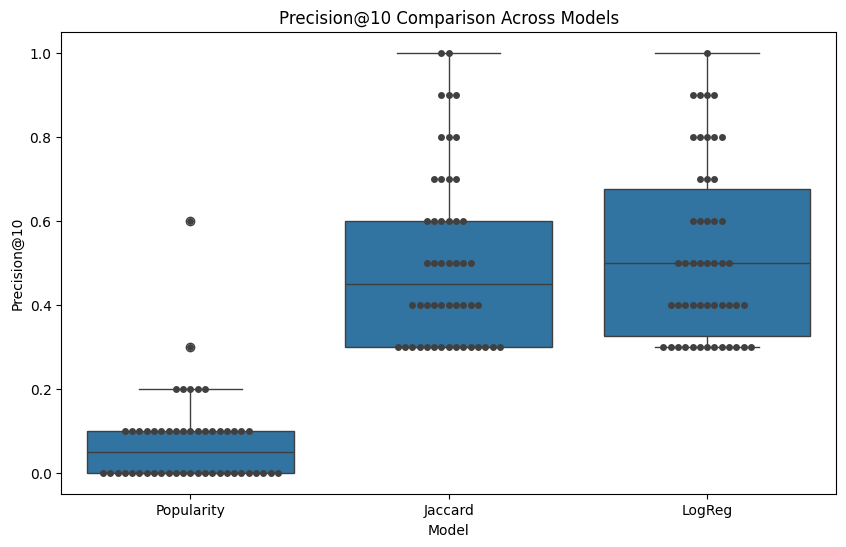

In [24]:
# Collect precision@10 for a sample of users
def get_model_precisions(users, model=None):
    precisions = []
    for u in users:
        eval_result = evaluate_user(u, model=model, topk=10)
        precisions.append(eval_result['precision_at_10'])
    return precisions

sample_users = eligible_users[:50] if len(eligible_users) > 50 else eligible_users

# Popularity baseline
pop_precisions = get_model_precisions(sample_users, model=None)

# Jaccard baseline
jaccard_precisions = []
for u in sample_users:
    user_titles = [stories_df.iloc[id_to_idx[i]]['title'] for i in user_interactions[u] if i in id_to_idx]
    j_scores = [(idx, jaccard_score(user_titles, stories_df.iloc[idx]['title'])) for idx in range(len(stories_df))]
    j_ranked = [i for i,s in sorted(j_scores, key=lambda x:-x[1])]
    true_idxs = [id_to_idx[i] for i in user_interactions[u] if i in id_to_idx]
    j_prec = precision_at_k(j_ranked, true_idxs, k=10)
    jaccard_precisions.append(j_prec)

# Logistic Regression
logreg_precisions = get_model_precisions(sample_users, model=model if 'model' in globals() else None)

plot_df = pd.DataFrame({
    'User': sample_users,
    'Popularity': pop_precisions,
    'Jaccard': jaccard_precisions,
    'LogReg': logreg_precisions
})

# Melt for seaborn
plot_df_melt = plot_df.melt(id_vars='User', value_vars=['Popularity','Jaccard','LogReg'],
                            var_name='Model', value_name='Precision@10')

plt.figure(figsize=(10,6))
sns.boxplot(x='Model', y='Precision@10', data=plot_df_melt)
sns.swarmplot(x='Model', y='Precision@10', data=plot_df_melt, color='.25')
plt.title('Precision@10 Comparison Across Models')
plt.show()

## Sources / Acknowledegments

Code partially generated using Copilot with GPT-5 mini and GPT-4.1.
All data was taken from Hacker News via Algolia API, and all real user data was anonymized.
Inspiration from this project was taken from Hacker News at [news.ycombinator.com/news](news.ycombinator.com/news), as well as an unofficial alternative frontend, hckr news at [hckrnews.com](hckrnews.com).